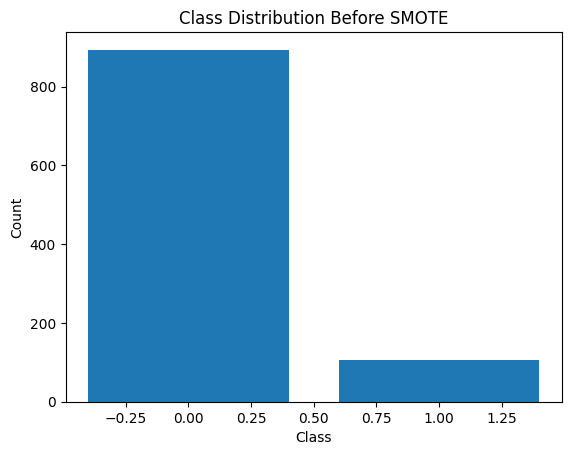

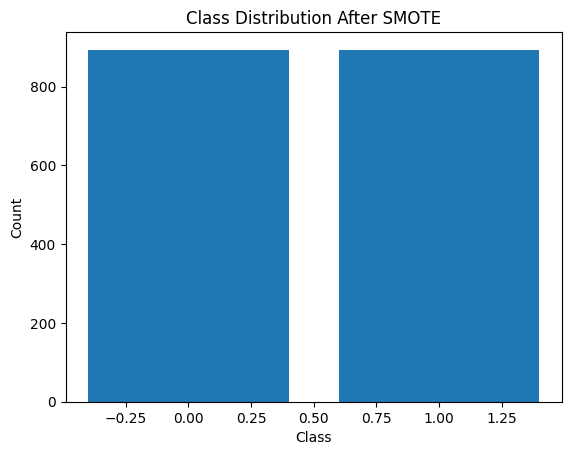

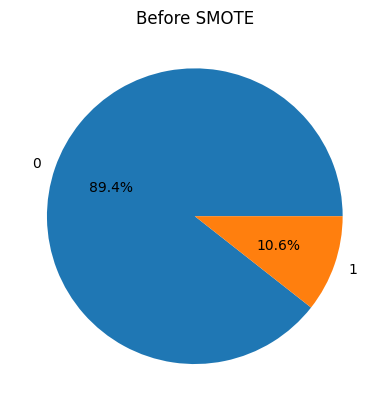

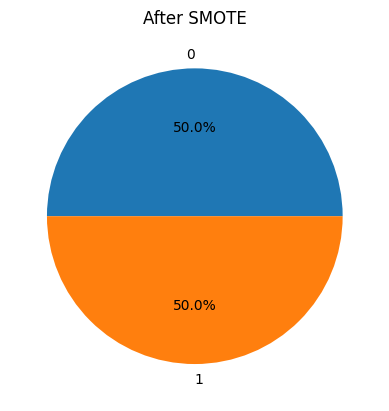

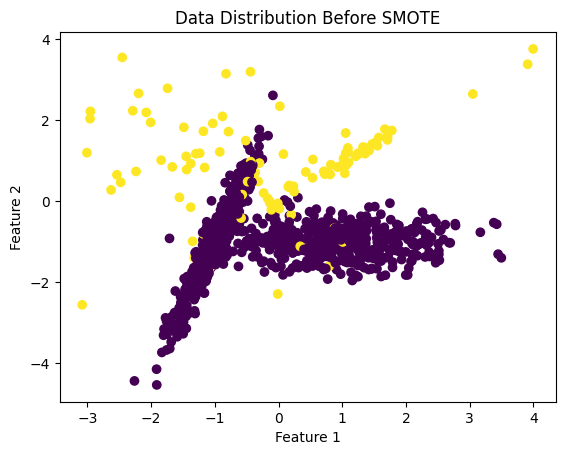

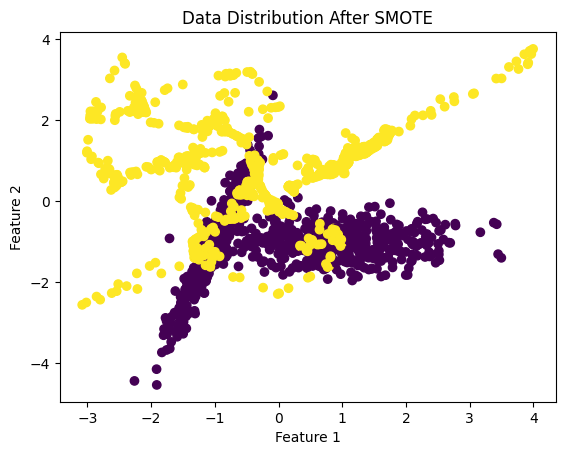

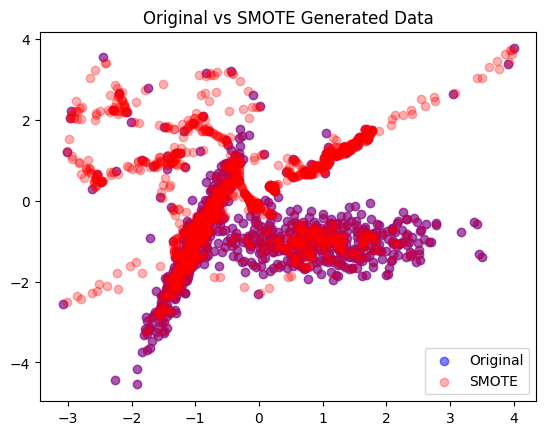

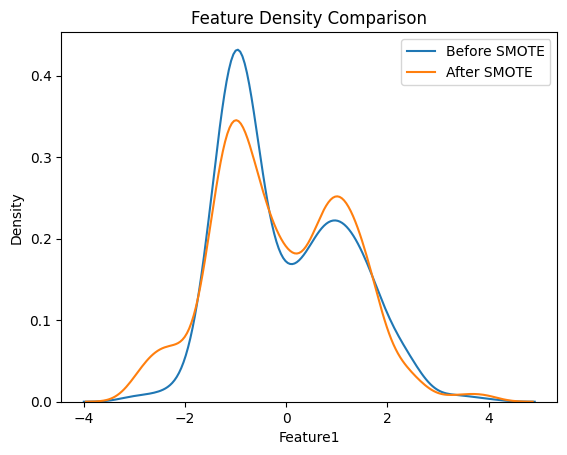

In [ ]:
# USAMA ANSARI (221206)

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
import seaborn as sns

# --------------------------------------------------
# STEP 1: Create Imbalanced Dataset
# --------------------------------------------------
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    weights=[0.9, 0.1],
    random_state=42
)

X_train = pd.DataFrame(X, columns=["Feature1", "Feature2"])
y_train = pd.Series(y)

# --------------------------------------------------
# STEP 2: Before SMOTE – Class Distribution
# --------------------------------------------------
counter_before = Counter(y_train)

plt.figure()
plt.bar(counter_before.keys(), counter_before.values())
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# --------------------------------------------------
# STEP 3: Apply SMOTE
# --------------------------------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# --------------------------------------------------
# STEP 4: After SMOTE – Class Distribution
# --------------------------------------------------
counter_after = Counter(y_resampled)

plt.figure()
plt.bar(counter_after.keys(), counter_after.values())
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# --------------------------------------------------
# STEP 5: Pie Charts
# --------------------------------------------------
plt.figure()
plt.pie(counter_before.values(), labels=counter_before.keys(), autopct='%1.1f%%')
plt.title("Before SMOTE")
plt.show()

plt.figure()
plt.pie(counter_after.values(), labels=counter_after.keys(), autopct='%1.1f%%')
plt.title("After SMOTE")
plt.show()

# --------------------------------------------------
# STEP 6: Scatter Plots
# --------------------------------------------------
plt.figure()
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train)
plt.title("Data Distribution Before SMOTE")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

plt.figure()
plt.scatter(X_resampled.iloc[:, 0], X_resampled.iloc[:, 1], c=y_resampled)
plt.title("Data Distribution After SMOTE")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# --------------------------------------------------
# STEP 7: Original vs SMOTE Overlay
# --------------------------------------------------
plt.figure()
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1],
            c='blue', alpha=0.5, label='Original')
plt.scatter(X_resampled.iloc[:, 0], X_resampled.iloc[:, 1],
            c='red', alpha=0.3, label='SMOTE')
plt.legend()
plt.title("Original vs SMOTE Generated Data")
plt.show()

# --------------------------------------------------
# STEP 8: Density Plot
# --------------------------------------------------
plt.figure()
sns.kdeplot(X_train.iloc[:, 0], label="Before SMOTE")
sns.kdeplot(X_resampled.iloc[:, 0], label="After SMOTE")
plt.title("Feature Density Comparison")
plt.legend()
plt.show()
